# Homework 1 Data Science and Unsupervised Learning

Joshua Ng  
MSE 298


## 2: Exploratory Data Analysis
### 2.1 Dataset Description

In [5]:
from matminer.datasets import load_dataset
df = load_dataset("ucsb_thermoelectrics")
print(df.head())
print(df.columns)

        composition    crystallinity                         synthesis  \
1  Ti0.99Nb0.01NiSn  Polycrystalline                Arc-melted, vacuum   
2          Cu1.98Se  Polycrystalline                    Melted, vacuum   
3            Bi2Te3   Single crystal                            Melted   
4        Cr1.3Mo6S8  Polycrystalline      Solid state reaction, vacuum   
5            LaNiO3  Polycrystalline  Evaporate nitrates (1173 K, air)   

   spacegroup  rho (ohm.cm)  S [muV/K]  PF [W/mK^2]        zT  kappa [W/mK]  \
1       216.0      0.001240   -192.458     0.002987  0.203822      5.861700   
2       225.0      0.003250    201.500     0.001249  1.230837      1.015000   
3       166.0      0.000450   -174.000     0.006728  0.502500      4.016716   
4         2.0      0.000693     51.220     0.000378  0.098456      2.690500   
5       167.0      0.004601    -25.760     0.000014       NaN           NaN   

   sigma [S/cm]   T [K]                                              src  
1    

This is a dataset of 1100 experimentally measured thermoelectric materials describing the thermoelectric properties of materials. The dataset contains electrical properties, chemical compositions, synthesis routes, crystal structures, and metadata about the experimental conditions and sources. The dataset references 108 publications and personal communications. 

The doi is 10.1021/cm400893e, and is under a open-source license as part of matminer. This is a structured dataset, and is in the format of a python dataframe the way it is imported. This is a dataset because I am taking the current iteration of a database of materials; the matminer library also provides "datasets". The specific dataset I am using "ucsb_thermoelectrics" has 18,000 datapoints.

### 2.2 Exploratory Data Analysis

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

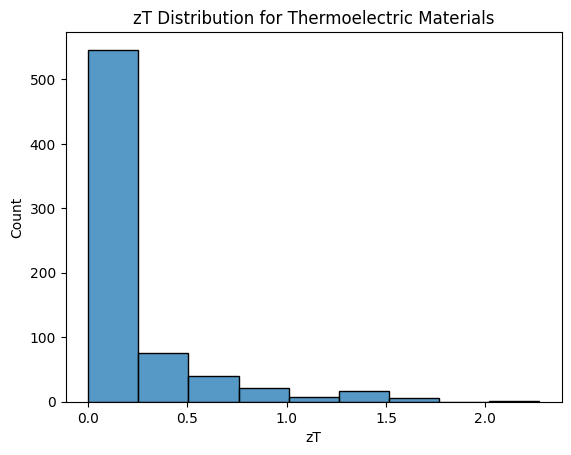

In [8]:
sns.histplot(data=df, x = "zT", binwidth=0.25)
plt.title("zT Distribution for Thermoelectric Materials")
plt.show()

The thermoelectric figure of merit is defined as:

$$ zT = \frac{\sigma S^{2} T}{\kappa}$$

where $\sigma$ is the electrical conductivity, S is the Seebeck coefficient, $\kappa$ is the thermal conductivity, and T is the difference in temperature. This is often used to calculate a material's efficiency at converting heat into voltage/power.

As a sanity check, I will plot zT against the tabulated values. Much of the dataset is missing the temperature difference, so I don't expect this to fit well, but for a general linear trend to appear.

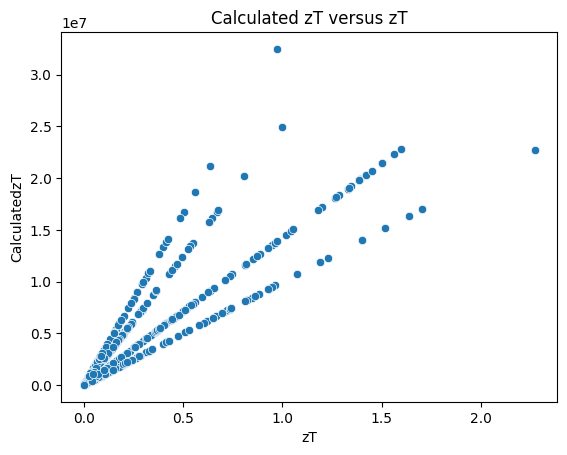

In [11]:
df["CalculatedzT"] = 1/df["rho (ohm.cm)"] * df['S [muV/K]']**2 / df['kappa [W/mK]'] # Assuming T is an arbitrary constant
sns.scatterplot(data = df, x = "zT", y = "CalculatedzT")
plt.title("Calculated zT versus zT")
plt.show()

There are four extremely linear groups. I suspect the main reason for this is different sources, but first let's conduct k-means clustering to see what the groups are, defining the main variable as $\frac{CalculatedzT}{zT}$.

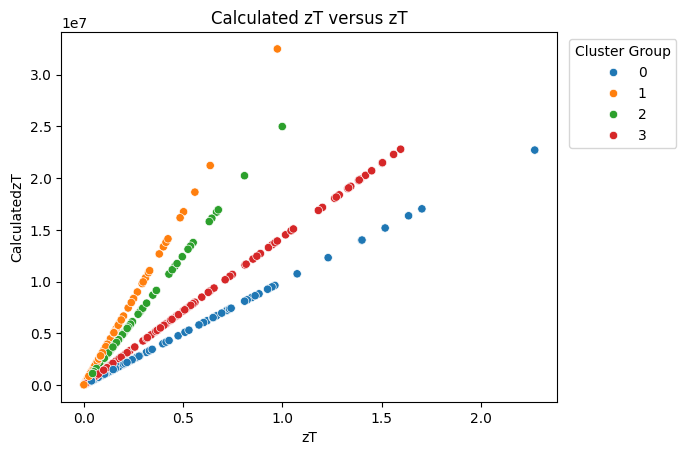

In [20]:
df = df.dropna()
df['CzT_zT'] = df['CalculatedzT']/(df['zT']+1e-9)

kmeans = KMeans(n_clusters=4)
df['clusters'] = kmeans.fit_predict(df[['CzT_zT']])
sns.scatterplot(data = df, x = "zT", y = "CalculatedzT", hue = 'clusters', palette = 'tab10')
plt.title("Calculated zT versus zT")
plt.legend(title = "Cluster Group", bbox_to_anchor = (1.01, 1), loc = 'upper left')
plt.show()


In [24]:
source_exclusivity = df.groupby('src')['clusters'].nunique()
independent_sources = source_exclusivity[source_exclusivity == 1]
shared_sources = source_exclusivity[source_exclusivity > 1]

print(f"Independent Sources (Only 1 cluster): {len(independent_sources)}")
print(f"Shared Sources (Across multiple clusters): {len(shared_sources)}")

Independent Sources (Only 1 cluster): 18
Shared Sources (Across multiple clusters): 69


The immediate intuition that the four groups come from different sources is largely incorrect, as most of the sources are shared between the clusters. 

In [51]:
source_exclusivity = df.groupby('T [K]')['clusters'].nunique()
independent_sources = source_exclusivity[source_exclusivity == 1]
shared_sources = source_exclusivity[source_exclusivity > 1]

print(f"Independent Temperatures (Only 1 cluster): {len(independent_sources)}")
print(f"Shared Temperatures (Across multiple clusters): {len(shared_sources)}")

cluster_mapping = df.groupby('clusters')['T [K]'].unique()

for cluster_id, temps in cluster_mapping.items():
    print(f"Cluster {cluster_id}: {temps[0]}")

Independent Temperatures (Only 1 cluster): 4
Shared Temperatures (Across multiple clusters): 0
Cluster 0: 1000.0
Cluster 1: 300.0
Cluster 2: 400.0
Cluster 3: 700.0


As it turns out, I misinterpreted my dataset and these are differences caused by the measurement temperature. After plotting the correct equation, using the T [K] column as the temperature, the data is perfectly linear. 

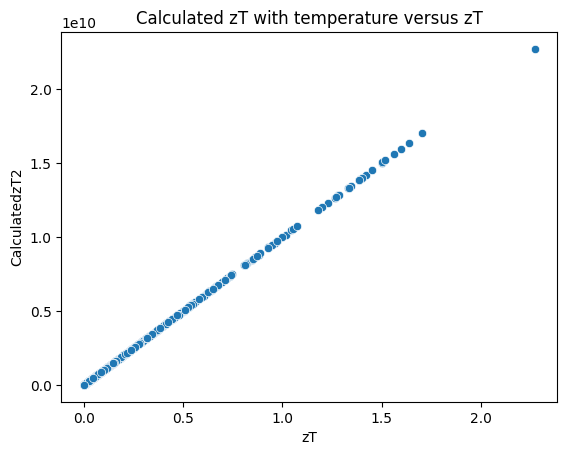

In [48]:
df["CalculatedzT2"] = 1/df["rho (ohm.cm)"] * df['S [muV/K]']**2 * df['T [K]']/ df['kappa [W/mK]'] # Assuming T is an arbitrary constant
sns.scatterplot(data = df, x = "zT", y = "CalculatedzT2")
plt.title("Calculated zT with temperature versus zT")
plt.show()

In [26]:
from pymatgen.core import Composition
def get_at_percent_dict(formula):
    try:
        comp = Composition(formula)
        # get_el_amt_dict() returns {Element: Stoichiometry}
        # comp.num_atoms is the sum of all coefficients
        return {str(el): (amt / comp.num_atoms) * 100 
                for el, amt in comp.get_el_amt_dict().items()}
    except Exception as e:
        # Useful for catching typos like "Gz" (not an element)
        print(f"Error parsing {formula}: {e}")
        return {}

df_elements = (
    df['composition']
    .apply(get_at_percent_dict)
    .apply(pd.Series)
)

df_sparse_elements = (
    df_elements
    .fillna(0.0)
    .astype(pd.SparseDtype("float64", 0.0))
)

df = pd.concat([df, df_sparse_elements], axis=1)
print(df.head())


        composition    crystallinity                            synthesis  \
1  Ti0.99Nb0.01NiSn  Polycrystalline                   Arc-melted, vacuum   
2          Cu1.98Se  Polycrystalline                       Melted, vacuum   
3            Bi2Te3   Single crystal                               Melted   
4        Cr1.3Mo6S8  Polycrystalline         Solid state reaction, vacuum   
7    Ba0.4Sr0.6PbO3  Polycrystalline  Solid state reaction (under oxygen)   

   spacegroup  rho (ohm.cm)  S [muV/K]  PF [W/mK^2]        zT  kappa [W/mK]  \
1       216.0      0.001240   -192.458     0.002987  0.203822      5.861700   
2       225.0      0.003250    201.500     0.001249  1.230837      1.015000   
3       166.0      0.000450   -174.000     0.006728  0.502500      4.016716   
4         2.0      0.000693     51.220     0.000378  0.098456      2.690500   
7        62.0      0.004128    -82.770     0.000166  0.021697      2.294800   

   sigma [S/cm]  ...    Y    P   Ga   Tb   Ru   Yb   Sm    I  

Performing PCA on the different temperatures independently because those are experimental design and do not reflect the material structure to property relationship at all.

The above correlated values are also being dropped in favor of just looking at the zT, as zT exactly captures the relationship between all of them.

c:\Users\joshu\anaconda3\envs\mse298hw0\Lib\site-packages\sklearn\utils\validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\joshu\anaconda3\envs\mse298hw0\Lib\site-packages\sklearn\utils\validation.py:888: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


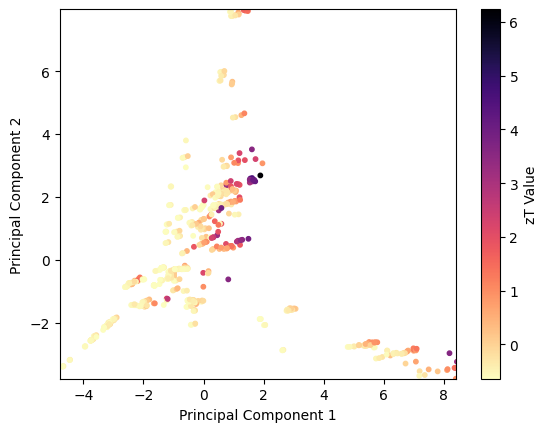

In [62]:
pca = PCA(n_components=2)
temp_groups = [1000, 300, 400, 700]

new_df = df.drop(columns = ['rho (ohm.cm)', 'T [K]', 'kappa [W/mK]', "S [muV/K]", "CalculatedzT", "CalculatedzT2", "CzT_zT", "clusters"])

df_numeric = new_df.select_dtypes(include=['number'])
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)
df_scaled = pd.DataFrame(scaled_data, columns=df_numeric.columns)

Z_pca = pca.fit_transform(df_scaled)

fig, ax = plt.subplots()

xlow, xhigh = np.quantile(Z_pca, [0.005, 0.995], axis=0)

im = ax.scatter(Z_pca[:, 0], Z_pca[:, 1], s=10, c=df_scaled['zT'], cmap = 'magma_r')
fig.colorbar(im, ax=ax, label='zT Value')
ax.set_xlim(xlow[0], xhigh[0])
ax.set_ylim(xlow[1], xhigh[1])

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")

plt.show()

In [70]:
weights_df = pd.DataFrame(
    pca.components_, 
    columns=df_numeric.columns, 
    index=[f'PC{i+1}' for i in range(pca.n_components)]
)

for pc in weights_df.columns:
    top_10_indices = weights_df[pc].abs().sort_values(ascending=False).head(10).index
    top_10_weights = weights_df.loc[top_10_indices, pc]
    
    print(top_10_weights)

PC1    0.240699
PC2    0.132387
Name: spacegroup, dtype: float64
PC1    0.245403
PC2   -0.002011
Name: PF [W/mK^2], dtype: float64
PC1    0.131854
PC2    0.091721
Name: zT, dtype: float64
PC1   -0.026488
PC2   -0.007022
Name: sigma [S/cm], dtype: float64


TypeError: DataFrame.sort_values() missing 1 required positional argument: 'by'

## 2.3 Summarize your insights

The physical equation for the thermoelectric figure of merit is perfectly conserved, indicating that this is a calculated value rather than a cross measured one:

$$ zT = \frac{\sigma S^{2} T}{\kappa}$$

where in the dataset, $\sigma$ is $\frac{1}{rho (ohm.cm)}$ in the dataset, S is "S [muV/K]", T is "T [K]", and $\kappa$ is "kappa [W/mK]".